# Data Exploration and Cleaning of GSAF Dataset

In [2]:
# Import necessary libraries.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Load the dataset and view the first 5 rows.
df = pd.read_csv('../data/processed/01_gsaf_tidy_data.csv')
df.head()

,Record_ID,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,Injury,Fatal Y/N,Time,Species,Source
0,7070,20th January,2026,Unprovoked,Australia,NSW,Point Plomber North of Port Macquarie,Surfing,Paul Zvirdinas,M,39,Minor cuts and abrasions,N,0830hrs,Bull shark,Bob Myatt GSAF
1,7069,19th January,2026,Unprovoked,Australia,NSW,Dee Why,Surfing,Unknown,M,11,None reported damage to board,N,1145hrs,Bull shark,Andy Currie
2,7068,19th January,2026,Unprovoked,Australia,NSW,North Steyne,Surfing,Andre de Ruyter,M,27,Serious Leg injuries,N,1820hrs,5m shark species not determined,9 News: Bob Myatt GSAF
3,7067,18th January,2026,Unprovoked,Australia,NSW,Nielsen Park Vaucluse Sydney Harbour,Jumping off rocks,Nico Antic,M,12,Serious leg injuries,Y,1620hrs,Bull shark,Bob Myatt GSAF
4,7066,10th January,2026,Unprovoked,Australia,NSW,Avalon Beach,Surfing,Paul Stanton,M,?,Puncture mark to left thumb,N,0540hrs,Unknown,Bob Myatt GSAF


In [4]:
# Inspect the data information, looking for data structure, data types, nulls
df.info()
# Age, time, species has a lot of nulls.
# Many data types that are object that should be string or numeric.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7070 entries, 0 to 7069
Data columns (total 16 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Record_ID  7070 non-null   int64 
 1   Date       7070 non-null   object
 2   Year       7070 non-null   int64 
 3   Type       7053 non-null   object
 4   Country    7020 non-null   object
 5   State      6583 non-null   object
 6   Location   6503 non-null   object
 7   Activity   6485 non-null   object
 8   Name       6851 non-null   object
 9   Sex        6491 non-null   object
 10  Age        4075 non-null   object
 11  Injury     7035 non-null   object
 12  Fatal Y/N  6509 non-null   object
 13  Time       3543 non-null   object
 14  Species    3939 non-null   object
 15  Source     7050 non-null   object
dtypes: int64(2), object(14)
memory usage: 883.9+ KB


In [5]:
# Inspect the column headings.
column_names = df.columns
print(F"\nCOLUMN NAMES:\n\n{column_names}")


COLUMN NAMES:

Index(['Record_ID', 'Date', 'Year', 'Type', 'Country', 'State', 'Location',
       'Activity', 'Name', 'Sex', 'Age', 'Injury', 'Fatal Y/N', 'Time',
       'Species ', 'Source'],
      dtype='object')


In [6]:
# Strip any white spaces from column names.
df.columns = df.columns.str.strip()

In [7]:
# Adjust the name of fatal column. 
df.rename({'Fatal Y/N': 'Fatal'}, axis=1, inplace=True)

In [8]:
# Convert non-numeric object data types to string, all at once.
obj_to_string = ['Type', 'Country', 'State', 'Location', 'Activity', 'Name', 'Sex', 'Injury', 'Fatal', 'Source', 'Species']
for col in obj_to_string:
    df[col] = df[col].astype('string')

## Type Column

In [10]:
# Inspect 'Type' column.
print(f"\nUNIQUE VALUES IN 'Type' COLUMN:\n\n{df['Type'].unique()}")


UNIQUE VALUES IN 'Type' COLUMN:

<StringArray>
[         'Unprovoked',            'Provoked',        'Questionable',
          'unprovoked',          'Watercraft',        'Sea Disaster',
                  <NA>,                   '?',         'Unconfirmed',
          'Unverified',             'Invalid', 'Under investigation',
                'Boat']
Length: 13, dtype: string


In [11]:
# Capitalize all category entries to create uniformity.
df['Type'] = df['Type'].str.capitalize()

In [12]:
# Boat can be categorized as Watercraft.
df['Type'] = df['Type'].replace(['Boat'], ['Watercraft'])

In [13]:
# Upon examining the data andk it's documentation, nulls and the following types will be categorized as Unknown for this use case. 
replace_data = ['Unconfirmed', 'Unverified', 'Invalid', 'Under investigation', 'Questionable', '?']
replacement = 'Unknown'
df['Type'] = df['Type'].replace(replace_data, replacement).fillna(replacement)

In [14]:
print(f"\nUNIQUE VALUES IN CLEANED 'Type' COLUMN:\n\n{df['Type'].unique()}")


UNIQUE VALUES IN CLEANED 'Type' COLUMN:

<StringArray>
['Unprovoked', 'Provoked', 'Unknown', 'Watercraft', 'Sea disaster']
Length: 5, dtype: string


## Fatal Column

In [16]:
print(f"\nUNIQUE VALUES IN 'Fatal' COLUMN:\n\n{df['Fatal'].unique()}")


UNIQUE VALUES IN 'Fatal' COLUMN:

<StringArray>
['N', 'Y', <NA>, 'n', 'UNKNOWN', 'N ', 'y']
Length: 7, dtype: string


In [17]:
# Remove white spaces and convertt all to upppercase.
df['Fatal']=df['Fatal'].str.strip().str.upper()
# Convert Nulls to UNKNOWN.
df['Fatal'] = df['Fatal'].fillna('UNKNOWN')

In [18]:
print(f"\nUNIQUE VALUES IN CLEANED 'Fatal' COLUMN:\n\n{df['Fatal'].unique()}")


UNIQUE VALUES IN CLEANED 'Fatal' COLUMN:

<StringArray>
['N', 'Y', 'UNKNOWN']
Length: 3, dtype: string


## Age Column

In [20]:
# Inspect the age column.
print(df['Age'].info())
# Look at the age metrics.
df['Age'].describe()

<class 'pandas.core.series.Series'>
RangeIndex: 7070 entries, 0 to 7069
Series name: Age
Non-Null Count  Dtype 
--------------  ----- 
4075 non-null   object
dtypes: object(1)
memory usage: 55.4+ KB
None


count     4075
unique     171
top         17
freq       174
Name: Age, dtype: object

In [21]:
# Convert age to numeric data type and any entries that contain non-numeric data to null.
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

In [22]:
# Create a missing flag for age before filling the nulls to preserve potential for 'unknown age' as an importanat feature.
df['Age_missing']=df['Age'].isna().astype(int)

In [23]:
# Impute 'Age' null with median age.
df['Age'] = df['Age'].fillna(df['Age'].median())

## Sex Column

In [25]:
# Inspect 'Sex' column.
print(f"\nUNIQUE VALUES IN 'Sex' COLUMN:\n\n{df['Sex'].unique()}")


UNIQUE VALUES IN 'Sex' COLUMN:

<StringArray>
['M', 'F', 'F ', 'M ', <NA>, 'm', 'lli', 'N', '.']
Length: 9, dtype: string


In [26]:
# Create uniformity for M and F values.
df['Sex'] = df['Sex'].str.strip().str.upper()

In [27]:
# Inspect unusual entries by creating a list and indexing the DataFrame to select the specific rows.
unusual = ['N', 'LLI', '.']
df_unusual = df.loc[df['Sex'].isin(unusual)]
df_unusual

,Record_ID,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,Injury,Fatal,Time,Species,Source,Age_missing
2363,4707,11-Nov-04,2004,Unprovoked,USA,California,Bunkers Humboldt Bay Eureka Humboldt County,Surfing,Brian Kang,LLI,38.0,Lacerations to hand knee & thigh,N,13h30,5.5 m [18'] white shark,R. Collier GSAF,0
5692,1378,11-Jul-34,1934,Watercraft,AUSTRALIA,New South Wales,Cronulla,Fishing,18' boat occupants William & Leslie Newton,N,24.0,No injury to occupants Sharks continually foll...,N,NaN,Blue pointer 11',G.P. Whitley ref: Daily Telegraph 7/11/1934 ...,1
6193,877,Reported 02-Jun-1908,1908,Sea disaster,PAPUA NEW GUINEA,New Britain,Matupi,.,<NA>,.,24.0,Remains of 3 humans recovered from shark but ...,Y,NaN,Allegedly a 33-foot shark,Taranaki Herald 6/2/1908,1
6891,179,Reported 18-Dec-1801,1801,Provoked,<NA>,<NA>,<NA>,Standing on landed shark's tail,Stephen Pettigew,N,24.0,FATAL PROVOKED INCIDENT,Y,NaN,12' shark,The Evening Post 12/18/1801,1


In [28]:
# Upon inspection, convert the two 'N's and 'LLI' to 'M'.
df['Sex'] = df['Sex'].replace(['N', 'LLI'], 'M')

In [29]:
# Convert remaining values and nulls to UNKNOWN.
df['Sex'] = df['Sex'].replace(['.'],['UNKNOWN']).fillna('UNKNOWN')

In [30]:
print(f"\nUNIQUE VALUES IN CLEANED 'Sex' COLUMN:\n\n{df['Sex'].unique()}")


UNIQUE VALUES IN CLEANED 'Sex' COLUMN:

<StringArray>
['M', 'F', 'UNKNOWN']
Length: 3, dtype: string


## Year Column

In [32]:
# Inspect 'Year' column (df.info() above showed no nulls to deal with).
print(f"\nNumber of unique 'Year' values: {df['Year'].nunique()}") 
print(f"\nUNIQUE VALUES IN 'Year' COLUMN:\n\n{df['Year'].unique()}")


Number of unique 'Year' values: 261

UNIQUE VALUES IN 'Year' COLUMN:

[2026 2016 2025 2024 2023 2022 2021 2020 2019 2018 2017 2015 2014 2013
 2012 2011 2010 2009 2008 2007 2006 2005 2004 2003 2002 2001 2000 1999
 1998 1997 1996 1995 1984 1994 1993 1992 1991 1990 1989 1969 1988 1987
 1986 1985 1983 1982 1981 1980 1979 1978 1977 1976 1975 1974 1973 1972
 1971 1970 1968 1967 1966 1965 1964 1963 1962 1961 1960 1959 1958 1957
 1956 1955 1954 1953 1952 1951 1950 1949 1948 1848 1947 1946 1945 1944
 1943 1942 1941 1940 1939 1938 1937 1936 1935 1934 1933 1932 1931 1930
 1929 1928 1927 1926 1925 1924 1923 1922 1921 1920 1919 1918 1917 1916
 1915 1914 1913 1912 1911 1910 1909 1908 1907 1906 1905 1904 1903 1902
 1901 1900 1899 1898 1897 1896 1895 1894 1893 1892 1891 1890 1889 1888
 1887 1886 1885 1884 1883 1882 1881 1880 1879 1878 1877 1876 1875 1874
 1873 1872 1871 1870 1869 1868 1867 1866 1865 1864 1863 1862 1861 1860
 1859 1858 1857 1856 1855 1853 1852 1851 1850 1849 1847 1846 1845 1844
 1842 

In [33]:
# Look entries for very old incidents.
oddity_df = df[df['Year'] <= 77]
oddity_df

,Record_ID,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,Injury,Fatal,Time,Species,Source,Age_missing
6939,131,Ca. 77 A.D.,77,Unprovoked,<NA>,Ionian Sea,<NA>,Sponge diving,males,M,24.0,FATAL,Y,NaN,<NA>,Perils mentioned by Pliny the Elder (23 A.D. t...,1
6940,130,Ca. 5 A.D.,5,Unprovoked,AUSTRALIA,New South Wales,Bondi,<NA>,male,M,24.0,Aboriginal rock carving depicts man being atta...,N,NaN,<NA>,Waverly Library,1
6941,129,Ca. 214 B.C.,0,Unprovoked,<NA>,Ionian Sea,<NA>,Ascending from a dive,Tharsys a sponge diver,M,24.0,FATAL shark/s bit him in two,Y,NaN,<NA>,Reported by Greek poet Leonidas of Tarentum (...,1
6942,128,Ca. 336.B.C..,0,Unprovoked,GREECE,Piraeus,In the haven of Cantharus,Washing his pig in preparation for a religious...,A candidate for initiation,M,24.0,"FATAL shark ""bit off all lower parts of him u...",Y,NaN,<NA>,Plutarch (45 - 125 A.D.) in Life of Phoecion (...,1
6943,127,Ca. 493 B.C.,0,Sea disaster,GREECE,Off Thessaly,<NA>,Shipwrecked Persian Fleet,males,M,24.0,Herodotus tells of sharks attacking men in the...,Y,NaN,<NA>,Herodotus (485 - 425 B.C.),1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7065,5,Before 1903,0,Unprovoked,AUSTRALIA,Western Australia,Roebuck Bay,Diving,male,M,24.0,FATAL,Y,NaN,<NA>,H. Taunton N. Bartlett p. 234,1
7066,4,Before 1903,0,Unprovoked,AUSTRALIA,Western Australia,<NA>,Pearl diving,Ahmun,M,24.0,FATAL,Y,NaN,<NA>,H. Taunton N. Bartlett pp. 233-234,1
7067,3,1900-1905,0,Unprovoked,USA,North Carolina,Ocracoke Inlet,Swimming,Coast Guard personnel,M,24.0,FATAL,Y,NaN,<NA>,F. Schwartz p.23 C. Creswell GSAF,1
7068,2,1883-1889,0,Unprovoked,PANAMA,<NA>,Panama Bay 8ºN 79ºW,<NA>,Jules Patterson,M,24.0,FATAL,Y,NaN,<NA>,The Sun 10/20/1938,1


In [34]:
# Look at the value counts per year.
year_count = df['Year'].value_counts().sort_index(ascending=False)
print(year_count.to_string())

Year
2026      8
2025     66
2024     52
2023    109
2022     98
2021    111
2020    101
2019    114
2018    124
2017    142
2016    134
2015    143
2014    126
2013    122
2012    117
2011    128
2010    101
2009    120
2008    122
2007    113
2006    103
2005    103
2004     92
2003     92
2002     88
2001     92
2000     97
1999     66
1998     65
1997     57
1996     61
1995     76
1994     57
1993     56
1992     56
1991     39
1990     39
1989     53
1988     56
1987     35
1986     39
1985     37
1984     41
1983     50
1982     42
1981     49
1980     36
1979     25
1978     26
1977     26
1976     39
1975     49
1974     39
1973     27
1972     36
1971     30
1970     42
1969     30
1968     47
1967     48
1966     58
1965     51
1964     66
1963     61
1962     86
1961     78
1960     93
1959     93
1958     54
1957     41
1956     51
1955     43
1954     45
1953     36
1952     29
1951     32
1950     43
1949     31
1948     29
1947     30
1946     26
1945     16
1944     31

In [35]:
# Records are very few and sparse before 1900, keep records from 1900 to 2025 for analysis.
df = df[df['Year'].between(1900, 2025)]

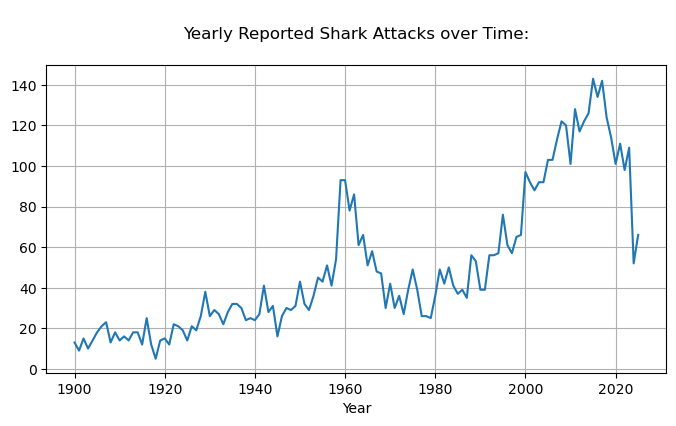

In [36]:
# Look at number of incident reports over time.
yearly_attacks = df.groupby('Year').size()
# Plot the line for visualization.
plt.figure(figsize=(8,4))
yearly_attacks.plot(kind='line', grid=1, title='\nYearly Reported Shark Attacks over Time:\n')
plt.show()

### The 1960 SPIKE: An international shark attack file was created in 1959 to collect data on attacks, contributing to the spike (https://siarchives.si.edu/blog/shark-attack-tracks).

## Country Column

In [39]:
# Inspect the unique country names.
country_names = df['Country'].unique().tolist()
print(f"\nUNIQUE COUNTRIES IN 'Country' COLUMN:\n\n{country_names}")


UNIQUE COUNTRIES IN 'Country' COLUMN:

['Australia', 'USA', 'French Polynesia', 'Samoa', 'Columbia', 'Costa Rica', 'Bahamas', 'Puerto Rico', 'Spain', 'Canary Islands', 'South Africa', 'Vanuatu', 'Jamaica', 'Israel', 'Mexico', 'Maldives', 'Philippines', 'Turks and Caicos', 'Mozambique', 'New Caledonia', 'Egypt', 'Thailand', 'New Zealand', 'Hawaii', 'Honduras', 'Indonesia', 'Morocco', 'Belize', 'Maldive Islands', 'Tobago', 'AUSTRALIA', 'INDIA', 'TRINIDAD', 'BAHAMAS', 'SOUTH AFRICA', 'MEXICO', 'NEW ZEALAND', 'EGYPT', 'BELIZE', 'PHILIPPINES', 'Coral Sea', 'SPAIN', 'PORTUGAL', 'SAMOA', 'COLOMBIA', 'ECUADOR', 'FRENCH POLYNESIA', 'NEW CALEDONIA', 'TURKS and CaICOS', 'CUBA', 'BRAZIL', 'SEYCHELLES', 'ARGENTINA', 'FIJI', 'MeXICO', 'ENGLAND', 'JAPAN', 'INDONESIA', 'JAMAICA', 'MALDIVES', 'THAILAND', 'COLUMBIA', 'COSTA RICA', 'British Overseas Territory', 'CANADA', 'JORDAN', 'ST KITTS / NEVIS', 'ST MARTIN', 'PAPUA NEW GUINEA', 'REUNION ISLAND', 'ISRAEL', 'CHINA', 'IRELAND', 'ITALY', 'MALAYSIA', 'L

In [40]:
# Convert all to uppercase for uniformity.
df['Country'] = df['Country'].str.upper()
# Trim white leading and lagging spaces.
df['Country'] = df['Country'].str.strip()
# Convert Countries followed by '?' to null due to uncertainty.
df['Country'] = df['Country'].replace(r'.*\?.*', np.nan, regex=True)
# Check null count.
print(f"NULL COUNT FOR 'Country' COLUMN: {df['Country'].isnull().sum()}")

NULL COUNT FOR 'Country' COLUMN: 25


In [41]:
# Convert nulls to UNKNOWN so they are not ignored in analysis.
df['Country'] = df['Country'].fillna('UNKNOWN')

In [42]:
# Examine country names that are oceans using boolean mask.
oceans = df['Country'].str.contains('OCEAN', na=False) 
unique_oceans = df.loc[oceans, 'Country'].unique().tolist()
print(f"\nUNIQUE OCEANS:\n{unique_oceans}")


UNIQUE OCEANS:
['ATLANTIC OCEAN', 'NORTH ATLANTIC OCEAN', 'PACIFIC OCEAN', 'SOUTH PACIFIC OCEAN', 'NORTH PACIFIC OCEAN', 'MID ATLANTIC OCEAN', 'SOUTH ATLANTIC OCEAN', 'RED SEA / INDIAN OCEAN', 'INDIAN OCEAN', 'SOUTHWEST PACIFIC OCEAN', 'MID-PACIFC OCEAN']


In [43]:
# Count the number or rows where 'Country' is an ocean.
ocean_count = df.loc[oceans, 'Country'].count()
print(f"\nINCIDENTS REPORTED WITH AN OCEAN IN THE 'Country' COLUMN: {ocean_count}")
# Look at value counts per ocean entry.
per_ocean_count = df.loc[oceans, 'Country'].value_counts()
print(f"\nOcean Value Counts: {per_ocean_count.to_string()}")


INCIDENTS REPORTED WITH AN OCEAN IN THE 'Country' COLUMN: 62

Ocean Value Counts: Country
PACIFIC OCEAN              15
ATLANTIC OCEAN             12
SOUTH ATLANTIC OCEAN        8
NORTH PACIFIC OCEAN         6
NORTH ATLANTIC OCEAN        5
MID ATLANTIC OCEAN          5
INDIAN OCEAN                5
SOUTH PACIFIC OCEAN         2
SOUTHWEST PACIFIC OCEAN     2
RED SEA / INDIAN OCEAN      1
MID-PACIFC OCEAN            1


In [44]:
# Red sea is part of the Indian Ocean, so categorize it as INDIAN OCEAN only.
df['Country'] = df['Country'].replace('RED SEA / INDIAN OCEAN', 'INDIAN OCEAN')
# Replace the "-" with a space in mid-pacific ocean for uniformity.
df['Country'] = df['Country'].replace('MID-PACIFC OCEAN', 'MID PACIFIC OCEAN')

In [45]:
# Examine countries with a "/" in their name.
combos = df['Country'].str.contains(r'/', na=False)
unique_combos = df.loc[combos, 'Country'].unique().tolist()
print("\nUNIQUE 'COMBO' COUNTRIES:")
unique_combos


UNIQUE 'COMBO' COUNTRIES:


['ST KITTS / NEVIS',
 'EGYPT / ISRAEL',
 'ANDAMAN / NICOBAR ISLANDAS',
 'IRAN / IRAQ',
 'SOLOMON ISLANDS / VANUATU',
 'ITALY / CROATIA']

In [46]:
# Look at value counts for the combined countries.
per_combo_count = df.loc[combos, 'Country'].value_counts()
print(F"\nCOMBINED COUNTRIES VALUE COUNTS:{per_combo_count.to_string()}")


COMBINED COUNTRIES VALUE COUNTS:Country
ST KITTS / NEVIS              1
EGYPT / ISRAEL                1
ANDAMAN / NICOBAR ISLANDAS    1
IRAN / IRAQ                   1
SOLOMON ISLANDS / VANUATU     1
ITALY / CROATIA               1


In [47]:
# Examine the combination country rows to help decide how to handle them.
df.loc[combos]

,Record_ID,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,Injury,Fatal,Time,Species,Source,Age_missing
440,6630,09-Jan-21,2021,Unprovoked,ST KITTS / NEVIS,The Narrows,Booby Island,Swimming / Kayaking,Brook Toussaint,F,26.0,Severe injury to left leg resulting in amputa...,N,09h00-10h00,<NA>,K. McMurray TrackingSharks.com,0
3031,4039,23-Jul-96,1996,Unprovoked,EGYPT / ISRAEL,South Sinai Gulf of Aqaba,1 km off the mouth of Marsa Bereika north of ...,Free diving with a pod of dolphins,Martin Christopher Richardson,M,24.0,Bitten on back shoulder & chest,N,18h00,said to involve an oceanic whitetip shark,Daily Telegraph 7/26/1996 p.15 K. Lavalli &...,1
4891,2179,13-Sep-58,1958,Unprovoked,ANDAMAN / NICOBAR ISLANDAS,<NA>,<NA>,"""Climbing up to ship after repairing the stern...",Sailor of tuna vessel Daisan-Tenyo-Maru,M,32.0,FATAL leg bitten,Y,14h00,Blue shark,M. Hosina,0
5373,1697,19-Aug-45,1945,Unprovoked,IRAN / IRAQ,Shatt-al-Arab River,Vicinity of Abadan,<NA>,Abdol Karmi,M,24.0,Lower left leg amputated,N,NaN,<NA>,A. Anderson M.D. / Lt. Col. R.S. Hunt Royal ...,1
5450,1620,13-Nov-42,1942,Sea disaster,SOLOMON ISLANDS / VANUATU,<NA>,North of Guadalcanal Solomon Islands while en...,Explosion & sinking of the USS Juneau after be...,Because of a mistaken belief that there were n...,M,24.0,Over a period of a week men in the water died ...,Y,11h01 -time of ship sinking,<NA>,US Navy Military History,1
5688,1382,Reported 26-Aug-1934,1934,Unknown,ITALY / CROATIA,<NA>,Kralievica,Swimming,Zorca Prinz,F,24.0,Reported to be FATAL and involve a 6m white s...,UNKNOWN,NaN,Invalid,C. Moore & R. Roccini GSAF D. Baldridge pp....,1


In [48]:
# Adjust the combination names using common sense.
df['Country'] = df['Country'].replace("ST KITTS / NEVIS", "ST KITTS AND NEVIS")
df['Country'] = df['Country'].replace("EGYPT / ISRAEL", "EGYPT")
df['Country'] = df['Country'].replace("ANDAMAN / NICOBAR ISLANDAS", "ANDAMAN AND NICOBAR ISLANDS")
df['Country'] = df['Country'].replace("IRAN / IRAQ", "IRAQ")
df['Country'] = df['Country'].replace("SOLOMON ISLANDS / VANUATU", "SOLOMON ISLANDS")
df['Country'] = df['Country'].replace("ITALY / CROATIA", "CROATIA")

In [49]:
# Make further adjustments for uniformity. 
df['Country'] = df['Country'].replace('UNITED ARAB EMIRATES (UAE)', 'UNITED ARAB EMIRATES')
df['Country'] = df['Country'].replace('ST. MARTIN', 'ST MARTIN')
df['Country'] = df['Country'].str.replace(r'&', 'AND')

In [50]:
print(f"NULL COUNT FOR 'Country': {df['Country'].isnull().sum()}")
# Convert nulls to UNKNOWN so they are not ignored in analysis.
df['Country'] = df['Country'].fillna('Unknown')

NULL COUNT FOR 'Country': 0


In [51]:
# Further inspect the 'Country' column.
print(f"\nNUMBER OF UNIQUE COUNTRIES IN CLEANED 'Country' COLUMN: {df['Country'].nunique()}")


NUMBER OF UNIQUE COUNTRIES IN CLEANED 'Country' COLUMN: 172


In [52]:
# Look at which countries have the most reported shark attacks.
top_countries = df['Country'].value_counts().nlargest(10)#.index
print(f"\nTEN COUNTRIES WITH THE MOST REPORTED SHARK ATTACKS:\n{top_countries.to_string()}")


TEN COUNTRIES WITH THE MOST REPORTED SHARK ATTACKS:
Country
USA                 2427
AUSTRALIA           1356
SOUTH AFRICA         569
BAHAMAS              132
PAPUA NEW GUINEA     132
BRAZIL               118
NEW ZEALAND          115
MEXICO                95
NEW CALEDONIA         64
ITALY                 62


## Date Column

In [54]:
# Inspect the 'Date' column. Leave as is since it will not be used for this project.
print(f"\nVALUE COUNTS FOR DATE ENTRY LENGTHS:\n{df['Date'].str.len().value_counts().to_string()}")


VALUE COUNTS FOR DATE ENTRY LENGTHS:
Date
9     5254
20     353
6      293
4      220
13      38
11      21
12      21
8       19
14      17
10      15
21      10
5       10
25      10
26       6
22       4
15       4
32       3
23       2
17       2
43       1
24       1
33       1
41       1
55       1
16       1
28       1
34       1
36       1


## Species Column

In [56]:
# Inspect 'Species' column.
print(f"\nNUMBER OF UNIQUE SHARK SPECIES: {df['Species'].nunique()}")
print(f"NULL COUNT FOR 'Species': {df['Species'].isnull().sum()}")


NUMBER OF UNIQUE SHARK SPECIES: 1683
NULL COUNT FOR 'Species': 2567


In [57]:
# Inspect the format of the 'Species' data.
df['Species'].unique().tolist()

['Great White Shark',
 'Suspected Great White Shark',
 'Black Tip Reef Shark',
 '3m Bull shark ',
 '3m shark',
 'Unknown',
 'Not stgated',
 'Suspected Tiger shark',
 'Nurse shark ',
 'Tiger or Bull shark',
 'Bronze whaler?',
 'unknown 1.2m shark',
 'Tiger shark 4m',
 'Not stated',
 '5m (16.5ft) Great White',
 'Undetermined',
 'Lemon shark 1.8 m (6ft)',
 'Suspected Great White',
 'Great White Shark est 3m (10ft)',
 'Lemon shark',
 '5ft (1.5m) Bull shark',
 'Undetermined small shall shark',
 'Undetermined ',
 '2m Bull shark?',
 'Sand Tiger shark',
 'Small shark',
 'Bull shark',
 'Great White',
 'Small shark 1m (3ft) long',
 'Dusky sharks',
 'Not Staed',
 '1.5m Tiger shark',
 'Not stated ',
 'Mako shark',
 'bull shark',
 '1.8m (6ft) bull shark',
 'Bronze whaler',
 'Described as a large terrifying animal',
 'Reportedly Tiger or Bull shark',
 'Great White Shart estimated 4.8m 16 ft',
 'Reportedly a Tiger Shark',
 'Unknown ',
 '1m shark species unknown',
 'Reported as a large Tiger shark',
 

In [58]:
# Convert to lowercase and fill nulls with 'unknown'.
df['Species'] = df['Species'].str.lower()
df['Species'] = df['Species'].fillna('unknown')

### Clean text data well enough to categorize species using the GSAF website as a guide (https://www.sharkattackfile.net/species.htm). Remaining species will be categorized as 'other'.


In [60]:
# look for great white sharks using a boolean mask and indexing the DataFrame.
whites = df['Species'].str.contains('great white', na=False) 
unique_whites = df.loc[whites, 'Species'].unique().tolist()
print(unique_whites)

['great white shark', 'suspected great white shark', '5m (16.5ft) great white', 'suspected great white', 'great white shark est 3m (10ft)', 'great white', 'great white shart estimated 4.8m 16 ft', 'reportedly a great white', 'great white 6.0m']


In [61]:
# After examining the results for species that don't match, categorize these as 'great white'.
df.loc[whites, 'Species'] = 'great white'

In [62]:
# Fix a couple I just happened to notice.
df['Species'] = df['Species'].replace('wfite shark', 'great white')
df['Species'] = df['Species'].replace('bu.ll', 'bull')

In [63]:
# Repeat the process until species are categorized.
whites2 = df['Species'].str.contains('white shark', na=False)
unique_whites2 = df.loc[whites2, 'Species'].unique().tolist()
print(unique_whites2)

['3m white shark', 'white shark', "white shark  13'", 'white shark  4.5 m', 'white shark  3.8-4.2m', 'juvenile white shark', 'white shark  3 m', "white shark  16'", 'white shark  3m', "white shark  6' to 8'", 'white shark  2-to 3m', 'white shark  4m', "white shark  11'?", 'white shark  2.5 m', 'white shark  3.5 m', 'white shark  2.5 to 3 m', 'white shark  4 m', 'juvenile white shark?', "14' white shark", 'white shark  juvenile', 'white shark  4.6m', "white shark  17' female", 'white shark  3.2m to 3.5m', 'white shark  5m female', "white shark  11'", 'juvenile white shark   2.7 to 3.2 m', 'white shark  4.6 m', 'white shark  3.5m', 'white shark  3 to 3.5m ', "white shark  5' to 7'", "white shark  10'", "white shark  11' to 13'", "white shark  8' to 10'", "white shark  9'", "white shark  female  14'", "white shark  10' to 12'", "white shark  19'", "white shark  11' to 12'", "white shark  10' to 12' ", 'white shark  3.9 to 4.2 m', "white shark  7'", 'white shark  2m to 3 m', 'white shark  

In [64]:
df.loc[whites2, 'Species'] = 'great white'

In [65]:
whites3 = df['Species'].str.contains('oceanic', na=False)
unique_whites3 = df.loc[whites3, 'Species'].unique().tolist()
print(unique_whites3)

['oceanic whitetip shark', 'oceanic whitetip shark  1.8 to 2 m', "oceanic whitetip shark'", "oceanic whitetip shark  7'", 'oceanic whitetip shark  2.5m ', 'oceanic whitetip shark  2.5m  female', "oceanic whitetip shark  6'", 'oceanic whitetip shark  2.5 to 3m', 'oceanic whitetip sharks were in the vicinity', '2.5 oceanic whitetip shark', 'said to involve an oceanic whitetip shark', "two 3 m [10'] oceanic whitetip sharks", 'oceanic whitetip shark x 2', 'oceanic whitetip shar   identified by dr. w.c. schoeder on photograph & dr. l.p. l. schultz on sketch by observer', "oceanic whitetip shark 1.8 m [6'] ", 'survivors said 2 species of sharks were involved:  oceanic whitetip sharks and another species', 'survivors said 2 species of sharks were involved:  oceanic whitetip sharks and another species ', "1.8 m to 2.4 m [6' to 8'] sharks  most were oceanic whitetip sharks", 'reportedly: oceanic whitetip sharks  blue sharks  tiger sharks & bull sharks']


In [66]:
df.loc[whites3, 'Species'] = 'oceanic whitetip'

In [67]:
sandtigers = df['Species'].str.contains('sandtiger', na=False)
unique_sandtigers = df.loc[sandtigers, 'Species'].unique().tolist()
print(unique_sandtigers)

["thought to involve a 4' sandtiger shark", 'sandtiger shark', "sandtiger shark'", "sandtiger shark  2'", "possibly a 5' to 6' sandtiger shark", "sandtiger shark  4' to 5'", "sandtiger shark  8'", "sandtiger shark  2.1 m [7'] ", 'possibily a  1.5 to 2 m sandtiger shark', "sandtiger shark  3 m [10'] ", "12' sandtiger shark", 'sandtiger shark  2 m  male ', "1.8 m [6'] sandtiger shark", "2.1 m [7'] sandtiger shark", 'lemon shark or sandtiger shark']


In [68]:
df.loc[sandtigers, 'Species'] = 'sandtiger'

In [69]:
tigers = df['Species'].str.contains('tiger', na=False)
unique_tigers = df.loc[tigers, 'Species'].unique().tolist()
print(unique_tigers)

['suspected tiger shark', 'tiger or bull shark', 'tiger shark 4m', 'sand tiger shark', '1.5m tiger shark', 'reportedly tiger or bull shark', 'reportedly a tiger shark', 'reported as a large tiger shark', 'bull or tiger 7-8ft', 'large tiger shark  ', 'reportedly tiger shark', 'not stated area has tiger and galapogas sharks', 'tiger shark', "tiger shark 8'", "8' tiger shark", "10' tiger shark", 'tiger shark?', 'tiger sharks', "tiger shark  13'", "tiger shark  8'-10'", 'tiger  shark?', 'sandtiger', 'oceaniic whitetip shark/tiger shark', 'oceaniic whitetip shark/tiger shark  2m shark', "tiger shark  15'", 'tiger shark  2 to 2.5m', 'tiger shark  3 m', '5 to 8-ff tiger shark', 'tiger shark  4 m', 'tiger shark. 14\'3"', 'tiger shark  4m ', '3.4 m tiger shark', "10'-12' tiger shark", 'tiger shark  4m to 5m', "tiger shark  10' to 12'", 'tiger shark  3m', "tiger shark  12'", 'tiger shark  female', 'tiger shark  8 to 10 feet', 'tiger shark  100 kg', "tiger shark  10'", "tiger shark  10' ", 'tiger

In [70]:
df.loc[tigers, 'Species'] = 'tiger'

In [71]:
lemons = df['Species'].str.contains('lemon', na=False)
unique_lemons = df.loc[lemons, 'Species'].unique().tolist()
print(unique_lemons)

['lemon shark 1.8 m (6ft)', 'lemon shark', "lemon shark  6'", 'sickelfin lemon shark  3m', "lemon shark  8'", 'lemon shark pup', "lemon shark  3'", 'sicklefin lemon shark ', "lemon shark  9'", 'lemon shark  3.5 m', "lemon shark  4'", "lemon shark  4' to 5' ", 'lemon shark  2.5m to 3m ', "possibly a 6' lemon shark", "lemon shark  6' female ", 'lemon shark  >1 m ', "lemon shark  2.1  m to 2.4 m [7' to 8'] ", "lemon shark  2.7 m [9'] ", "lemon shark  1.5 m [5']  identified  by the surfer", "lemon shark  4' ", 'bull shark or lemon shark', 'lemon shark  30-lb ', "2.7 m [9'] bull or lemon shark", "lemon shark  1.8 m to 2.4 m [6' to 8']  tooth fragment recovered", 'lemon shark  2 m [6\'9"]', "2.1 m [7'] lemon shark or bull shark", "lemon shark  9' ", 'lemon shark  0.5 m', 'lemon shark ', 'lemon shark  1164 mm  immature male  identified by  v.g. springer', 'lemon shark  1.8 m [6\'] male  n. breviostris  identified by w.a. stark ii  later the same day a 6\'8" pregnant female lemon shark bit the

In [72]:
df.loc[lemons, 'Species'] = 'lemon'

In [73]:
bulls = df['Species'].str.contains('bull', na=False)
unique_bulls = df.loc[bulls, 'Species'].unique().tolist()
print(unique_bulls)

['3m bull shark ', '5ft (1.5m) bull shark', '2m bull shark?', 'bull shark', '1.8m (6ft) bull shark', 'bull shark 6ft', 'bull shark 6-7ft', 'bull shark 6 ft', 'not specified bull shark highly suspect', 'bull shark 3m ', "bull shark  7'", '1.8m bull shark', "bull shark  4'", "bull shark  6'", 'bull', "bull shark  9'", 'bull shark  3m', 'bull shark  +100kg', 'said to involve a bull shark', 'whaler or bull shark  2m', 'bull shark  80cm', '3m bull shark', "bull shark  6.5 to 10 '", "bull shark. 6.5'", "bull shark  4' to 6'", 'juvenile bull shark?', "bull shark  8'", 'bull shark pup', "bull shark  4' to 5'", 'bull shark  3.5 m', 'bull shark?', "said to involve a bull shark  5' to 6'", 'juvenile bull shark', 'bull shark  2 m', 'bull shark  3 m ', 'bull shark  2m', "bull shark  5' to 7'", 'bull shark  1.5', 'bull shark  4 m', 'bull shark  1 m', 'bull sharks x 2', 'bull shark  2.8 to 3.1 m', "bull shark  5'", 'bull shark  2.5 m', 'bull shark  1.3 m', "bull shark  3' to 4'", "bull shark  4.5' ",

In [74]:
df.loc[bulls, 'Species'] = 'bull'

In [75]:
makos = df['Species'].str.contains('mako', na=False)
unique_makos = df.loc[makos, 'Species'].unique().tolist()
print(unique_makos)

['mako shark', 'mako shark  4 juvenile', "mako shark  7'", "mako shark  1.5 m [5'] ", 'mako shark  100-lb', "mako shark  5'", 'mako shark ', 'mako shark  3m', 'mako shark  90kg', 'thought to involve a mako shark  but possibly a sea lion', "longfin mako shark  3.5 m [11.5']  350-kg [772-lb] ", "mako shark  1.8 m [6']", "mako shark  3 m to 4 m [10' to 13'] ", 'shortfin mako shark', "mako shark  3 m [10']", 'mako shark  400-lb ', "mako shark  2 m [6.75'] ", "mako shark  14' ", "shortfin mako shark  3 m to 3.4 m [10' to 11'] ", 'mako shark  1.3 m gaffed ', "mako shark  4.3 m [14']", "mako shark  1.8 m [6']  ", "mako shark  3 m [10']  200-kg [441-lb] ", 'mako shark (tooth fragments recovered)', 'mako shark  2.3 m  150-kg  ', 'mako shark  180-kg [397-lb]', "mako shark  3 m [10'] ", "shortfin mako shark  2.3 m [7.5'] ", "mako shark  1.9 m [6.5'] ", "1.5 m to 2.1 m [5' to 7'] shark  possibly a mako shark", "2.1 m [7']  90-kg mako shark", "mako shark  1.8 m to 2.1 m [6' to 7']  with hook & wire

In [76]:
df.loc[makos, 'Species'] = 'mako'

In [77]:
makos2 = df['Species'].str.contains('blue pointer', na=False)
unique_makos2 = df.loc[makos2, 'Species'].unique().tolist()
print(unique_makos2)

['blue pointer', "blue pointer  16'", "blue pointer  11' ", "blue pointer  12'"]


In [78]:
df.loc[makos2, 'Species'] = 'mako'

In [79]:
nurse = df['Species'].str.contains('nurse', na=False)
unique_nurse = df.loc[nurse, 'Species'].unique().tolist()
print(unique_nurse)

['nurse shark ', "nurse shark  5' to 6'", 'nurse shark', 'juvenile nurse shark', 'small nurse shark', 'nurse shark  juvenile', "nurse shark  5'", 'grey nurse shark  3 m female', 'tawny nurse shark  2m', "nurse shark. 5'", "nurse shark  4'", 'tawny nurse shark', "nurse shark  2'", 'nurse shark  2.5-ft', 'tawney nurse shark  1m', 'nurse shark?', 'grey nurse shark  3m', 'tawny nurse shark  40cm', 'grey nurse shark', 'nurse shark  juvenile ', "nurse shark  6'", "nurse shark  10'", "nurse shark  2' to 3' ", "nurse shark  3' ", "nurse shark  60 cm to 90 cm [2' to 3'] ", "1.5 m [5'] shark  either a bronze whaler or a grey nurse shark", "thought to involve a 2 m [6.75'] grey nurse shark", "nurse shark  1.5 m [5'] ", 'nurse shark  1m ', "nurse shark  1.5 m [5']", "nurse shark  1.2 m [4'] ", "nurse shark  0.9 m [3'] ", "nurse shark  0.9 m  [3'] ", "nurse shark  3'  20-lb ", 'grey nurse shark  2 m', "grey nurse shark  10' ", "grey nurse shark  11'", 'nurse shark  106 cm  28-lb  male ', 'nurse sha

In [80]:
df.loc[nurse, 'Species'] = 'nurse'

In [81]:
blackreef = df['Species'].str.contains('black tip reef', na=False) 
unique_blackreef = df.loc[blackreef, 'Species'].unique().tolist()
print(unique_blackreef)

['black tip reef shark']


In [82]:
df.loc[blackreef, 'Species'] = 'blacktip reef'

In [83]:
blackreef2 = df['Species'].str.contains('blacktip reef', na=False) 
unique_blackreef2 = df.loc[blackreef2, 'Species'].unique().tolist()
print(unique_blackreef2)

['blacktip reef', 'blacktip reef shark', "blacktip reef shark 5'", 'blacktip reef shark  juvenile', 'blacktip reef shark ', 'blacktip reef shark  1m', 'possibly a blacktip reef shark', 'blacktip reef shark pup', 'a 10-year-old 94-pound pregnant blacktip reef shark', "blacktip reef shark  1.5 m [5'] "]


In [84]:
df.loc[blackreef2, 'Species'] = 'blacktip reef'

In [85]:
blacktip = df['Species'].str.contains('black tip', na=False)
unique_blacktip = df.loc[blacktip, 'Species'].unique().tolist()
print(unique_blacktip)

['"black tipped" shark']


In [86]:
df.loc[blacktip, 'Species'] = 'blacktip'

In [87]:
blacktip2 = df['Species'].str.contains('blacktip', na=False) & (df['Species'] != 'blacktip reef') #exclude blacktip reef from the mask
unique_blacktip2 = df.loc[blacktip2, 'Species'].unique().tolist()
print(unique_blacktip2)

['4-5ft blacktip shark', 'blacktip', 'blacktip shark', 'blacktip shark?', 'atlantic blacktip shark', "blacktip shark  5' to 6'", 'blacktip or spinner shark', 'small blacktip shark', 'blacktip whaler       carcharhinus tilstoni  2m', "blacktip shark  6'", "blacktip shark  6' to 7'", 'juvenile blacktip shark', "5' blacktip shark", "4' to 5' blacktip shark", "blacktip shark  5' ", 'said to involve a blacktip shark', 'possibly a juvenile blacktip shark', "blacktip shark  4'", 'blacktip shark  juvenile', "blacktip shark  4' to 5'", "blacktip or spinner shark  4'", 'spinner shark or blacktip shark', 'blacktip or spinner shark?', 'small blacktip shark?', 'blacktip shark ', 'blacktip shark pup', 'possibly a small blacktip shark', 'blacktip shark  2m', "blacktip shark  5'", '1.8 m blacktip "reef" shark', "possibly a 1' to 3' blacktip or spinner shark", 'possibly a sandbar shark or small blacktip shark', "1.8 m [6'] blacktip shark", "1.2 m [4'] blacktip shark", "1.2 m [4'] blacktip or sandbar sh

In [88]:
df.loc[blacktip2, 'Species'] = 'blacktip'

In [89]:
blue = df['Species'].str.contains('blue shark', na=False)
unique_blue = df.loc[blue, 'Species'].unique().tolist()
print(unique_blue)

['blue shark', 'blue shark  47kg', 'some drowned but other may have been killed by blue sharks', "blue shark 6'", 'blue shark  8 to 9 feet', 'blue shark  2.5m', 'blue shark  70-kg blue shark', "blue shark  7'", 'possibly a blue shark', 'blue shark  1m', '100-kg [221-lb] dead blue shark', 'blue shark ', 'small blue shark', 'blue sharks', 'blue shark  2m ', "8' blue shark", "5' blue shark", "blue shark  1.5 m [5'] ", "blue shark  3 m [10']", 'blue shark?', "blue shark  1.8 m [6'] ", "5' thresher or blue shark. the shark  was killed following the incident", "blue shark  8' [2.4 m]  500-lb ", 'blue shark  4.5 m [14\'9"]', '"a blue shark"', "blue shark  4' ", "said to involve  9' blue shark"]


In [90]:
df.loc[blue, 'Species'] = 'blue'

In [91]:
whaler = df['Species'].str.contains('whaler', na=False)
unique_whaler = df.loc[whaler, 'Species'].unique().tolist()
print(unique_whaler)

['bronze whaler?', 'bronze whaler', 'broze whaler?', "bronze whaler  6'", 'bronze whaler shark  1.5 m', 'bronze whaler shark  2m', 'bronze whaler shark  2 m', 'bronze whaler shark', 'bronze whaler 1.5m', 'bronze whaler 2.5m', 'bronze whaler sharks x 3', "bronze whaler shark  6'", 'bronze whaler shark  1.5m', 'bronze whaler shark  2.5m', 'bronze whaler shark  3m', 'possibly a bronze whaler shark', 'bronze whaler shark?', 'bronze whaler shark  4m', 'bronze whaler shark  1.5 m ', 'bronze whaler shark  a  juvenile ', "bronze whaler shark  4.3 m [14'] ", "bronze whaler shark  2 m to 3 m [6.75' to 10']  ", "bronze whaler shark  2.4 m [8'] ", "bronze whaler shark  2.5 m [8.25'] ", "bronze whaler shark  1.5 m [5'] ", '1.5 m [5\'] "whaler shark"', "bronze whaler shark  2.5 m [8.25']  k", 'bronze whaler shark  2 m ', 'bronze whaler shark  3 m', "bronze whaler shark  2.3 m [7.5'] ", '2 m shark  possibly a bronze whaler', "bronze whaler shark  3 m [10'] ", 'bronze whaler shark  2 m to 3 m ', 'bron

In [92]:
df.loc[whaler, 'Species'] = 'whaler'

In [93]:
hammer = df['Species'].str.contains('hammer', na=False)
unique_hammer = df.loc[hammer, 'Species'].unique().tolist()
print(unique_hammer)

['hammerhead sp.', 'hammerhead shark', 'hammerhead shark.', "hammerhead shark. 6' to 7'", 'thought to involve a juvenile hammerhead shark', 'possibly a hammerhead shark', 'small hammerhead shark', "8' great hammerhead shark", 'reported to involve a hammerhead shark', "1' to 2' hammerhead or bonnethed shark", "1.8 m to 2.1 m [6' to 7'] hammerhead shark", '3 m hammerhead shark', '2 m hammerhead', "1.8 m to 2.4 m [6' to 8'] hammerhead shark", 'possibly a small hammerhead shark', 'hammerhead shark?+o2356', "1.2 m to 1.5 m [4' to 5'] hammerhead shark", "3.5' hammerhead shark", '1 m hammerhead shark', "1.5 m [5'] hammerhead shark", "2 scalloped hammerhead sharks  1.5 m & 1.8 m [5' & 6']", 'a small hammerhead shark', "1.2 m [4'] hammerhead shark", 'hammerhead shark  500-llb ', "hammerhead shark  1.8 m [6'] ", 'a hammerhead shark  then 8 to 10 other sharks were said to be  involved', "hammerhead shark  9' ", "hammerhead shark  1.8 m [6'] s. zygena identified by c. limbaugh on description", "ha

In [94]:
df.loc[hammer, 'Species'] = 'hammerhead'

In [95]:
wobbegong = df['Species'].str.contains('wobbegong', na=False)
unique_wobbegong = df.loc[wobbegong, 'Species'].unique().tolist()
print(unique_wobbegong)

['wobbegong shark', 'possibly a wobbegong', 'wobbegong shark?', 'wobbegong shark  1 m', 'wobbegong shark  2m', 'wobbegong shark  1.6 to 1.8m ', 'wobbegong  2m', 'wobbegong shark  1.6m', 'wobbegong shark  60cm', 'wobbegong shark  2 m ', "wobbegong shark  1.2 m [4'] k", "wobbegong shark  1.2 m [4'] ", 'wobbegong shark  1m', 'wobbegong shark ', "wobbegong shark  5' ", 'wobbegong', "wobbegong shark  3' ", 'wobbegong shark  1.4 m [4\'6"] ', "wobbegong shark  o. barbatus   1.8 m [6']  identified by g.p. whitley", "wobbegong shark  1.4 m [4.6'] ", "wobbegong shark  1.5 m [5'] ", "wobbegong shark  1.8 m [6'] ", "wobbegong shark  4' ", "wobbegong shark  4'", "wobbegong shark  6'"]


In [96]:
df.loc[wobbegong, 'Species'] = 'wobbegong'

In [97]:
spinner = df['Species'].str.contains('spinner', na=False)
unique_spinner = df.loc[spinner, 'Species'].unique().tolist()
print(unique_spinner)

["spinner shark  4'?", 'spinner shark', 'spinner shark  4 to 5 feet', "spinner shark  7'", "spinner shark  5'", "6' shark  possibly a blactip or spinner shark", 'a small spinner shark', "spinner shark  6'", 'possibly a spinner shark', "spinner shark  3' to 4' ", "spinner shark  1.2 m to 1.5 m [4' to 5'] ", "5' spinner shark", "1.2 m [4'] shark (spinner shark?)", "1.2 m [4'] spinner shark", "4' spinner shark", "2.1 m [7'] shark  possibly a spinner shark"]


In [98]:
df.loc[spinner, 'Species'] = 'spinner'

In [99]:
#has to be grey AND reef b/c many strings describing grey coloured shark, which could be anything
grey = df['Species'].str.contains('grey reef', na=False)
unique_grey = df.loc[grey, 'Species'].unique().tolist()
print(unique_grey)

['grey reef shark  2 m', 'grey reef shark 1.5m', "grey reef shark  4' ", 'grey reef shark', 'grey reef shark. 2 m', 'grey reef shark ', "grey reef shark  5' to 8' ", "grey reef shark  2 m [6.75'] ", "grey reef shark  1.2 m [4'] ", 'grey reef shark  1.5 m ', '1.5 m grey reef shark', "1.8 m [6'] grey reef shark", "grey reef shark  1.8 m [6'] grey reef shark  identified by dr. l.p. l. schultz based on photographs  identified as c. melanopterus by stewart"]


In [100]:
df.loc[grey, 'Species'] = 'grey reef'

In [101]:
galapagos = df['Species'].str.contains('galapagos', na=False)
unique_galapagos = df.loc[galapagos, 'Species'].unique().tolist()
print(unique_galapagos)

["10' to 12' galapagos shark", 'galapagos shark', "galapagos shark  5'-9'", 'galapagos shark?', 'hand found in gut of 2.9 m to 3.3 m [9\'7" to 10\'11"] galapagos shark  c. galapagensis']


In [102]:
df.loc[galapagos, 'Species'] = 'galapagos'

In [103]:
carib = df['Species'].str.contains('bean', na=False) #use just bean to catch spelling errors
unique_carib = df.loc[carib, 'Species'].unique().tolist()
print(unique_carib)

['carribean reef shark 7ft', 'caribbean rreef shark', 'caribbean reef shark', "caribbean reef shark  4.5'", "caribbean reef shark  7' to 8'", "caribbean reef shark  6'", 'caribbean reef sharks', "1.8 m [6'] caribbean reef shark", "1 5 m [5'] caribbean reef shark (carcharhinus  perezi)", "1.8 m to 2.1 m [6' to 7']\xa0 caribbean reef shark ", "caribbean reef shark  1.2 m to 1.5 m [4' to 5'] ", 'possibly a caribbean reef shark', "1.5 m [5'] caribbean reef shark", "1.5 m to 2 m [5' to 6.75'] caribbean reef shark "]


In [104]:
df.loc[carib, 'Species'] = 'caribbean reef'

In [105]:
dusky = df['Species'].str.contains('dusky', na=False)
unique_dusky = df.loc[dusky, 'Species'].unique().tolist()
print(unique_dusky)

['dusky sharks', 'dusky shark  2m', "dusky shark  12' ", 'small dusky shark or blackfin shark', "1.2 m [4'] dusky shark", "1.5 m [5'] dusky shark", 'juvenile dusky shark', 'dusky shark  1 m ', "dusky shark  2.7 m [9'] dusky shark c. obscurus identified by s. springer on tooth recovered", "2.4 m [8'] shark  possibly a dusky shark", "atkins' remains were recovered from a dusky shark  c. obscurus  by capt. w. f. young  shark fisherman"]


In [106]:
df.loc[dusky, 'Species'] = 'dusky'

In [107]:
silky = df['Species'].str.contains('silky', na=False)
unique_silky = df.loc[silky, 'Species'].unique().tolist()
print(unique_silky)

["silky shark  6.5'", '1.8 m silky shark', "2.7 m [9'] silky shark", "silky shark  1.9 m [6.5']"]


In [108]:
df.loc[silky, 'Species'] = 'silky'

In [109]:
gray = df['Species'].str.contains('gray reef shark', na=False)
unique_gray = df.loc[gray, 'Species'].unique().tolist()
print(unique_gray)

['gray reef shark']


In [110]:
df.loc[grey, 'Species'] = 'grey reef'

In [111]:
seven = df['Species'].str.contains('seven', na=False)
unique_seven = df.loc[seven, 'Species'].unique().tolist()
print(unique_seven)

['sevengill shark', 'broadnose seven gill shark', 'broadnose seven gill shark?', 'seven-gill shark', 'broadnose sevengill shark  1.5 m', "sevengill shark  6' to 8'", 'broadnose sevengill shark', "2 m [6.75'] sevengill  shark", "sevengill shark  2.4 m [8'] ", "2 m to 2.5 m [6.75'  to 8.25'] sixgill or sevengill shark", 'sevengill shark  2.4 m', "sevengill  shark  1.2 m [4'] "]


In [112]:
df.loc[seven, 'Species'] = 'sevengill'

In [113]:
six = df['Species'].str.contains('sixgill', na=False)
unique_six = df.loc[six, 'Species'].unique().tolist()
print(unique_six)

[]


In [114]:
df.loc[six, 'Species'] = 'sixgill' # NOT NEEDED IF NONE FOUND.

In [115]:
basking = df['Species'].str.contains('basking', na=False)
unique_basking = df.loc[basking, 'Species'].unique().tolist()
print(unique_basking)

['basking shark']


In [116]:
df.loc[basking, 'Species'] = 'basking'

In [117]:
df['Species'] = df['Species'].replace('questionable', 'unknown')

In [118]:
df['Species'] = df['Species'].replace('invalid', 'unknown')

In [119]:
top_species = df.groupby('Species').size().nlargest(50)
top_species

Species
unknown                                              2691
great white                                           702
tiger                                                 337
bull                                                  226
blacktip                                              119
nurse                                                 110
shark involvement prior to death was not confi...     105
shark involvement not confirmed                        91
whaler                                                 84
mako                                                   63
wobbegong                                              55
lemon                                                  49
blue                                                   45
hammerhead                                             44
4' shark                                               43
6' shark                                               41
questionable incident                                  37
1.8 m 

In [120]:
# Enlisted help with example from GenAI on this code to help filter out more shark species by looking at words that come before the word shark.
target = 'shark'
df['leading_word'] = df['Species'].str.extract(rf'(\w+)(?=\s+{target})')

filtered_df = df.dropna(subset=['leading_word'])
filtered_df

,Record_ID,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,Injury,Fatal,Time,Species,Source,Age_missing,leading_word
14,7056,9th November,2025,Unprovoked,FRENCH POLYNESIA,Marquesas Islands,Hakahau Bay,Swimming,Not stated (Dentist),M,40.0,Deep Gash to bicep,N,Not stated,3m shark,Andrew Currie,0,3m
21,7049,29th September,2025,Unprovoked,USA,Off California,Catalina Island,Swimming,Christopher Murray,M,54.0,Leg and foot injury,N,0100hrs,unknown 1.2m shark,Todd Smith: Kevin McMurray Trackingsharks.com,0,2m
39,7031,6th July,2025,Unprovoked,USA,Florida,New Smyrna Beach,Surfing,Unknown Male,M,40.0,Lacerations to right arm,N,1500hrs,undetermined small shall shark,Todd Smith:Kevin McMurray Trackingsharks.com: ...,0,shall
43,7027,22nd June,2025,Unprovoked,USA,South Carolina,Coligny Beach Hilton Head Island,Swimming,Teenage girl,F,24.0,Laceration to lower right leg,N,1210hrs,small shark,Todd Smith: WJCL22 News: The Island Packet: KVNU:,1,small
50,7020,08-May-25,2025,Unprovoked,JAMAICA,Montego Bay,Rose Hall beach,Paddling,Rachel Smith,F,26.0,minor injuries to fingers of left hand,N,Not stated,small shark 1m (3ft) long,The sun News: Metro: Kevin McMurray Tracking s...,0,small
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6175,895,26-Jun-09,1909,Unprovoked,SOUTH AFRICA,Western Cape Province,Cape Town,<NA>,<NA>,M,24.0,Remains of soldier in uniform. Probable drowni...,Y,NaN,18-foot shark,Adams County News 6/26/1909,1,foot
6186,884,21-Sep-1908,1908,Unprovoked,AUSTRALIA,Torres Strait,Thursday Island,Fell from the jetty,Kong Choong Ting,M,24.0,FATAL,Y,NaN,remains recovered from 3 sharks,Northern Territory Times & Gazette 9/25/1908,1,3
6193,877,Reported 02-Jun-1908,1908,Sea disaster,PAPUA NEW GUINEA,New Britain,Matupi,.,<NA>,UNKNOWN,24.0,Remains of 3 humans recovered from shark but ...,Y,NaN,allegedly a 33-foot shark,Taranaki Herald 6/2/1908,1,foot
6231,839,Reported 05-Jul-1906,1906,Unprovoked,USA,Mississippi,Bay St. Louis Hancock County,Swimming,a St. Stanislaus College student,M,24.0,FATAL,Y,NaN,fishermen recovered partial remains from shark...,The Courier 7/5/1906,1,from


In [121]:
filtered_df['leading_word'].unique().tolist()

['3m',
 '2m',
 'shall',
 'small',
 '1m',
 'reef',
 'ft',
 '6ft',
 'large',
 '5m',
 'sandbar',
 'raggedtooth',
 'cookiecutter',
 'horn',
 '6m',
 'while',
 'epaulette',
 'no',
 'tope',
 'juvenile',
 '4m',
 'a',
 'whitetip',
 'm',
 'angel',
 'as',
 'salmon',
 'dogfish',
 'but',
 'foot',
 'goblin',
 'metre',
 'cow',
 'gill',
 'porbeagle',
 'jackson',
 'zambesi',
 '30kg',
 'thresher',
 'whale',
 'kg',
 'smoothhound',
 'sand',
 'silvertip',
 'same',
 'copper',
 '2',
 'brown',
 'colored',
 'captive',
 'finned',
 'soupfin',
 'young',
 'leopard',
 'unidentified',
 'grey',
 'female',
 'two',
 'lb',
 'gaffed',
 'zambezi',
 '50',
 'gray',
 'carpet',
 'dog',
 '6',
 'for',
 '8',
 'cm',
 'red',
 'banjo',
 'hooked',
 'larger',
 'several',
 'another',
 'little',
 'of',
 'bonita',
 'shovelnose',
 'nose',
 'nosed',
 '3',
 'cocktail',
 '7',
 'carcharhinid',
 'whiptail',
 'the',
 'saw',
 'from']

In [122]:
# Put identified species in the correct category, everything else is 'unknown'.
put_in_other = ['reef', 'sandbar', 'raggedtooth', 'cookiecutter', 'horn', 'epaulette', 'angel', 'salmon', 'dogfish', 'goblin', 'cow', 'porbeagle', 'jackson',
          'zambesi', 'thresher', 'whale', 'smoothhound', 'sand', 'silvertip', 'brown', 'soupfin', 'leopard', 'zambezi', 'carpet', 'dog', 'banjo',
          'bonita', 'shovelnose', 'whiptail',]
df.loc[df['leading_word'].isin(put_in_other), 'Species'] = 'other'

In [123]:
# Once leading words get categorized, convert them to null in the 'leading_word' column.
df.loc[df['leading_word'].isin(put_in_other), 'leading_word'] = np.nan

In [124]:
copper = ['copper']
df.loc[df['leading_word'].isin(copper), 'Species'] = 'whaler'

In [125]:
df['Species'] = df['Species'].replace('whaler', 'bronze whaler')

In [126]:
whitetip = ['whitetip']
df.loc[df['leading_word'].isin(whitetip), 'Species'] = 'oceanic whitetip'

In [127]:
make_null = ['copper', 'whitetip']
df.loc[df['leading_word'].isin(make_null), 'leading_word'] = np.nan

In [128]:
# Clean up remaining identified sharks, then make shark categories list , set rest to unknown.
other_sharks =['7-gill shark', 'porbeagle  1.5 m', 'small catsharks', ''"3' small spotted catshark  scyliorhinus canicula"'', 
               'shovelnose "shark" which is a ray  not a shark)', '"sandshark"', "horn shar k heterodontus francisci  1.2 m [4']",
              '"gummy" shark (rhizoprionodon or loxodon) 1.2 m [4\']', 'spurdog', "1.8 m [6'] dogfish", 'galapagos', 'silky', 'dusky']
df['Species'] = df['Species'].replace(other_sharks, 'other')

df['Species'] = df['Species'].replace('white xhark', 'great white')

sharklist = ['great white', 'blacktip reef', 'bull', 'tiger', 'nurse', 'bronze whaler', 'lemon', 'dusky', 'mako', 'blacktip', 
             'caribbean reef', 'oceanic whitetip', 'galapagos', 'blue', 'wobbegong', 'grey reef', 'other', 'spinner', 
             'hammerhead', 'silky']
sharks_mask = df['Species'].isin(sharklist)
df.loc[~sharks_mask, 'Species'] = 'unknown'

In [129]:
print(f"\nFINAL SPECIES CATEGORIES:\n\n{df['Species'].unique()}")


FINAL SPECIES CATEGORIES:

<StringArray>
[     'great white',    'blacktip reef',             'bull',
          'unknown',            'tiger',            'nurse',
    'bronze whaler',            'lemon',            'other',
             'mako',         'blacktip',   'caribbean reef',
 'oceanic whitetip',             'blue',        'wobbegong',
        'grey reef',          'spinner',       'hammerhead']
Length: 18, dtype: string


In [130]:
# Drop leading_word column.
df = df.drop('leading_word', axis=1)

In [131]:
# Drop source column, not needed for this project.
df = df.drop('Source', axis=1)

## Activity Column

In [133]:
# Inspect 'Activity' column.
df['Activity'].nunique()

1399

In [134]:
# Convert all to lowercase.
df['Activity'] = df['Activity'].str.lower()

In [135]:
# Examine the top 50 to get an idea of the data.
activity = df.groupby('Activity').size().nlargest(50)
print(f"\nTop 50 activities involved in reported shark attacks:\n\n{activity}")


Top 50 activities involved in reported shark attacks:

Activity
surfing                           1139
swimming                           893
fishing                            442
spearfishing                       391
wading                             170
snorkeling                         133
diving                             125
standing                           106
scuba diving                       103
bathing                             76
body boarding                       69
boogie boarding                     60
body surfing                        54
swimming                            44
kayaking                            40
treading water                      33
free diving                         31
pearl diving                        22
windsurfing                         20
walking                             17
floating                            16
kayak fishing                       16
fishing                             15
shark fishing                       15

In [136]:
# Check null count.
print(f"\nNULL COUNT FOR 'Activity' COLUMN: {df['Activity'].isnull().sum()}")


NULL COUNT FOR 'Activity' COLUMN: 471


In [137]:
# Convert nulls to 'unknown'.
df['Activity']=df['Activity'].fillna('unknown')

In [138]:
# Clean up 'Activity' column a bit to make top 10-20 categories more accurate. Same method as with 'Species'.
spears = df['Activity'].str.contains('spearfishing', na=False) 
unique_spears = df.loc[spears, 'Activity'].unique().tolist()
print(unique_spears)

['spearfishing', 'spearfishing / diving', 'spearfishing / free diving', 'free diving / spearfishing', 'spearfishing (free diving)', 'spearfishing/ filming', 'free diving & spearfishing', 'kayaking (returning from spearfishing)', 'spearfishing  carrying his catch', 'spearfishing  holding mesh bag with speared fish', 'spearfishing  but swimming at surface', 'spearfishing & holding catch', 'spearfishing & diving for paua', 'spearfishing on scuba & transferring fish onto a stringer', 'spearfishing / night diving', 'free diving & spearfishing (ascending)', 'free diving / spearfishing  from paddleboard & floating on the surface', 'scuba diving & spearfishing', 'spearfishing using scuba & trailing a string of bleeding fish', 'free diving & spearfishing ', 'spearfishing on scuba', 'free diving  & spearfishing (submerged)', 'free diving & spearfishing (descending)', 'spearfishing ', 'spearfishing  but swimming on surface', 'scuba diving  reportedly also spearfishing', 'free diving spearfishing'

In [139]:
df.loc[spears, 'Activity'] = 'spearfishing'

In [140]:
spears2 = df['Activity'].str.contains('spear', na=False) 
unique_spears2 = df.loc[spears2, 'Activity'].unique().tolist()
print(unique_spears2)

['spearfishing', 'spearishing', 'washing sand off a speared fish', 'snorkeling  carrying a speared fish in her hand', 'crabbing (spearing crabs)', 'free diving  carrying speargun', 'spearing fish', 'fishing  two large sharks passed. he speared one and it bit him', 'fishing  speared shark upset canoe & man fell in water', 'speared a grouper  saw shark but it came for him instead of the fish so he fired spear into shark’s mouth. then shark took grouper but unable to swallow because of the spear in its mouth.', 'spear fishing  removing fish from spear', 'spear fishing', 'line fishing from lakotoi  saw shoal of fish  dived overboard  had speared second fish & surfaced for air', 'swimming with speared fish', 'spearing a shark', 'fishing  had just speared a ulua']


In [141]:
df.loc[spears2, 'Activity'] = 'spearfishing'

In [142]:
# Now create a mask for all colomns with any type fishing, except spearfishing.
spear_mask = (df['Activity'].str.contains('fishing', case=False, na=False)) & (~df['Activity'].str.contains('spearfishing', case=False, na=False))
unique_spear_mask = df.loc[spear_mask, 'Activity'].unique().tolist()
print(unique_spear_mask)

['fishing', 'fishing/swimming', 'fishing was pulled of boat by shark', 'kayak fishing', 'fishing for sharks', 'fishing  fell in water', 'fell off fishing boat', 'surf fishing', 'fishing / filming sharks feeding on whale carcass', 'kayaking fishing', 'fishing ', 'fishing / wading', 'kayaking / fishing', 'lobster fishing', 'fishing for shrimp', 'shark fishing', 'fishing for blue sharks', 'attempting to remove fishing net from submerged object', 'longline fishing for sharks', 'fly fishing', "fishing - 'tag & release'", 'crayfishing', 'fishing (illegally)', 'wade fishing', 'diving / fishing', 'shark fishing on the ricardo astorga', 'shark fishing on the don agustín-vi. ', 'surf fishing / wading', 'fishing boat swamped in storm', 'fishing from surfski', 'fishing for snapper', 'fishing from a kayak', 'diving & fishing with net', 'wading / fishing & carrying a bag of fish', 'fishing for squid aboard the trawler shikishima-maru when the shark leapt into the boat', 'five men on makeshift raft a

In [143]:
df.loc[spear_mask, 'Activity'] = 'fishing'

In [144]:
swim = df['Activity'].str.contains('swimming', na=False) 
unique_swim = df.loc[swim, 'Activity'].unique().tolist()
print(unique_swim) 

['swimming', 'swimming with sharks', 'swimming - jumped off yacht', 'swimming - diving ', 'unconfirmed possibly swimming near the boat harbour', 'swimming ocean training ', 'swimming  or snorkeling', 'swimmingq', 'swimming / kayaking', 'swimming after being swept off rocks', 'swimming/ treading water', 'swimming/standing', 'swimming  poaching abalone', 'swimming / wading', 'swimming after falling overboard', 'swimming / snorkeling', 'marathon swimming', 'swimming ', 'swimming & snorkeling', 'swimming to shore with floatioon devices after boat engine conked out', 'swimming or boogie boarding', 'wading or swimming', 'swimming or snorkeling', 'swimming /  whale watching', 'swimming after boat became disabled', 'swimming / treading water', 'swimming to shore from capsized kayak', 'swimming  attempting to rescue a girl  believed to be drowning', 'swimming  towing surfboard', 'swimming or surfing', 'swimming / jumping off a jetty', 'swimming / body surfing', 'swimming with boogie board', 'sw

In [145]:
df.loc[swim, 'Activity'] = 'swimming'

In [146]:
surf = df['Activity'].str.contains('surfing', na=False) 
unique_surf = df.loc[surf, 'Activity'].unique().tolist()
print(unique_surf)

['surfing', 'surfing (hydrofoiling)', 'kite surfing', 'windsurfing', 'kite-surfing', 'wing foil surfing', 'body surfing', 'body-surfing', 'surfing ', 'body surfing?', 'bodysurfing', 'surfing & filming dolphins', 'body surfing or boogie boarding', 'kitesurfing', 'paddle-surfing', 'walking out of the water after surfing', 'night surfing', 'standing / surfing', 'treading water/ surfing', 'tandem surfing', 'surfing amid a shoal of sharks', 'boogie boarding or surfing', 'surfing  but standing in water alongside board', 'surfing  fell off surfboard & stepped on the shark.', 'windsurfing  but sitting on his board', 'surfing / wading', 'surfing (sitting on his board)', 'surfing  lying on surfboard', 'wading to shore after surfing', 'body surfing or body boarding', 'surfing (or body boarding)', 'surfing (lying prone on his board)', 'body boarding or surfing', 'walking / surfing', 'wading / surfing', 'body surfing  stood up on sandbar', 'wind surfing', 'surfing  sitting on board', 'surfing  padd

In [147]:
df.loc[surf, 'Activity'] = 'surfing'

In [148]:
df['Activity'] = df['Activity'].replace('boogie boarding', 'body boarding')

In [149]:
# Keep top 11 to including unknown and put the remaining lesser entries in 'other' category, to equal 12 categories.
top11 = df['Activity'].value_counts().nlargest(11).index


In [150]:
df.loc[~df['Activity'].isin(top11), 'Activity'] = 'Other'

In [151]:
print(f"\n UNIQUE VALUES IN CLEANED 'Activity' COLUMN:\n\n{df['Activity'].unique()}")


 UNIQUE VALUES IN CLEANED 'Activity' COLUMN:

<StringArray>
[ 'scuba diving',      'swimming',       'surfing',         'Other',
       'fishing',    'snorkeling',  'spearfishing',        'wading',
        'diving',       'unknown', 'body boarding',      'standing']
Length: 12, dtype: string


## State Column

In [153]:
# Convert nulls to 'unknown' and leave as is. 'State' will only be used for a map visualization.
df['State']=df['State'].fillna('unknown')

## Location Column

In [155]:
# Convert nulls to 'unknown' and leave as is. 'Location' will only be used for a map visualization.
df['Location']=df['Location'].fillna('unknown')

## Name Column

In [157]:
# Convert nulls to 'unknown' and leave as is. Names will likely not be used in this project.
df['Name']=df['Name'].fillna('unknown')

## Injury Column

In [159]:
# Convert nulls to 'unknown' and leave as is.'Injury' will likely not be used in this project.
df['Injury']=df['Injury'].fillna('unknown')

## Time Column

In [161]:
# Convert nulls to 'unknown' and leave as is.'Time' will likely not be used in this project.
df['Time']=df['Time'].fillna('unknown')

## Final Check

In [163]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6311 entries, 7 to 6319
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Record_ID    6311 non-null   int64  
 1   Date         6311 non-null   object 
 2   Year         6311 non-null   int64  
 3   Type         6311 non-null   string 
 4   Country      6311 non-null   string 
 5   State        6311 non-null   string 
 6   Location     6311 non-null   string 
 7   Activity     6311 non-null   string 
 8   Name         6311 non-null   string 
 9   Sex          6311 non-null   string 
 10  Age          6311 non-null   float64
 11  Injury       6311 non-null   string 
 12  Fatal        6311 non-null   string 
 13  Time         6311 non-null   object 
 14  Species      6311 non-null   string 
 15  Age_missing  6311 non-null   int32  
dtypes: float64(1), int32(1), int64(2), object(2), string(10)
memory usage: 813.5+ KB


In [164]:
df.head(10)

,Record_ID,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,Injury,Fatal,Time,Species,Age_missing
7,7063,21st December,2016,Unprovoked,AUSTRALIA,Western Australia,Ocean Reef North Perth,scuba diving,Tanveer Dhillon,M,24.0,None to report,N,?,great white,1
8,7062,21st December,2025,Unprovoked,USA,California,Lovers Point Pacific Grove,swimming,Erica Fox,F,55.0,Taken by shark body recovered with multiple in...,Y,1200hrs,great white,0
9,7061,12th December,2025,Unprovoked,USA,Sonoma County California,Salmon Creek,surfing,Unknown,M,24.0,Hand Injury,N,0800hrs,great white,1
10,7060,9th December,2025,Provoked,USA,Hawaii West Coast Big Island,Ka'alu'alu Beach,Other,Josiah Kaimani Ventura,M,24.0,Bite wounds to thigh,N,1630hrs,blacktip reef,0
11,7059,27th November,2025,Unprovoked,AUSTRALIA,NSW,Crowdy Bay,swimming,Lukas Schindler,M,26.0,Serious leg injuries,N,0630hrs,bull,0
12,7058,27th November,2025,Unprovoked,AUSTRALIA,NSW,Crowdy Bay,swimming,Livia Mulheim,F,25.0,Not stated,Y,0630hrs,bull,0
13,7057,10th November,2025,Unprovoked,AUSTRALIA,Western Australia,Prevelly Beach Magaret River,Other,Andy McDonald,M,61.0,No Injury to self,N,1745hrs,great white,0
14,7056,9th November,2025,Unprovoked,FRENCH POLYNESIA,Marquesas Islands,Hakahau Bay,swimming,Not stated (Dentist),M,40.0,Deep Gash to bicep,N,Not stated,unknown,0
15,7055,5th November,2025,Unprovoked,USA,Hawaii,Pine Trees Hanalei Bay Kaui,swimming,Chance Swanson,M,24.0,Injuries to legs,N,Mid afternoon,unknown,1
16,7054,5th November,2025,Unprovoked,USA,Texas,Matagorda Beach Matagorda,fishing,Chuck Bledsoe,M,24.0,Laceration on top and undermeath right foot,N,Not stated,unknown,1


In [165]:
# Save cleaned DataFrame to a .csv file for use in PowerBI for data visualization.
# df.to_csv('02_gsaf_cleaned_data.csv', index=False)

## Further Data Manipulation and Transformation for Machine Learning Purposes

In [167]:
# To reduce high cardinality issues I ran into after trying some initial ML model runs, sort countries into categories.
# Keep the top 15 as is.
top_countries = df['Country'].value_counts().nlargest(15).index 
top_countries

Index(['USA', 'AUSTRALIA', 'SOUTH AFRICA', 'BAHAMAS', 'PAPUA NEW GUINEA',
       'BRAZIL', 'NEW ZEALAND', 'MEXICO', 'NEW CALEDONIA', 'ITALY',
       'PHILIPPINES', 'REUNION', 'FIJI', 'MOZAMBIQUE', 'EGYPT'],
      dtype='string', name='Country')

In [168]:
# Put all oceans into one 'OPEN_OCEAN' category.
df.loc[oceans, 'Country'] = 'OPEN_OCEAN'

In [169]:
# Use a boolean mask for categories to keep, along with unknowns.
keep_countries_mask = (df['Country'].isin(top_countries)) | (df['Country'].str.contains('UNKNOWN', case=False, na=False))
unique_keep_countries_mask = df.loc[keep_countries_mask, 'Country'].unique().tolist()
print(unique_keep_countries_mask)

['AUSTRALIA', 'USA', 'BAHAMAS', 'SOUTH AFRICA', 'MEXICO', 'PHILIPPINES', 'MOZAMBIQUE', 'NEW CALEDONIA', 'EGYPT', 'NEW ZEALAND', 'BRAZIL', 'FIJI', 'PAPUA NEW GUINEA', 'ITALY', 'UNKNOWN', 'REUNION']


In [170]:
# Place remaining countries in 'OTHER' category.
df.loc[~keep_countries_mask, 'Country'] = 'OTHER'

In [171]:
print(f"\nNUMBER OF UNIQUE VALUES NOW IN 'Country' COLUMN:{df['Country'].nunique()}")


NUMBER OF UNIQUE VALUES NOW IN 'Country' COLUMN:17


In [172]:
print(f"\nCOUNTRY VALUE COUNTS:\n\n{df['Country'].value_counts()}")


COUNTRY VALUE COUNTS:

Country
USA                 2427
AUSTRALIA           1356
OTHER                947
SOUTH AFRICA         569
BAHAMAS              132
PAPUA NEW GUINEA     132
BRAZIL               118
NEW ZEALAND          115
MEXICO                95
NEW CALEDONIA         64
ITALY                 62
PHILIPPINES           61
REUNION               58
FIJI                  57
MOZAMBIQUE            47
EGYPT                 46
UNKNOWN               25
Name: count, dtype: Int64


In [173]:
# Drop columns that will not be used in ML.
drop_cols = ['Record_ID', 'Date', 'State', 'Location','Name', 'Injury', 'Time']
df = df.drop(drop_cols, axis=1)

In [174]:
df.shape

(6311, 9)

In [175]:
# 'Fatal' column will be the target for ML.
df['Fatal'].unique()

<StringArray>
['N', 'Y', 'UNKNOWN']
Length: 3, dtype: string

In [176]:
# Remove rows with unknowns.
df = df[df['Fatal'] != 'UNKNOWN']

In [177]:
df.shape

(5771, 9)

In [178]:
# Direct mapping for binary classification: 1 for Yes, 0 for No
df['Fatal'] = df['Fatal'].map({'Y': 1, 'N': 0})

In [179]:
# Inspect final DataFrame.
df.head()

,Year,Type,Country,Activity,Sex,Age,Fatal,Species,Age_missing
7,2016,Unprovoked,AUSTRALIA,scuba diving,M,24.0,0,great white,1
8,2025,Unprovoked,USA,swimming,F,55.0,1,great white,0
9,2025,Unprovoked,USA,surfing,M,24.0,0,great white,1
10,2025,Provoked,USA,Other,M,24.0,0,blacktip reef,0
11,2025,Unprovoked,AUSTRALIA,swimming,M,26.0,0,bull,0


In [180]:
# Save to csv to read into machine learning notebook.
# df.to_csv('03_gsaf_ml_data.csv', index=False)